In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("powerplant_data.csv")

In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
# AT => Temperature
# V =>  Vaccum
# AP => Pressure
# RH => Humidity

# PE => Produced Energy

In [5]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [6]:
X=df.drop(columns=["PE"])

y=df["PE"]

In [7]:
X.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


In [8]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [9]:
#split your data

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [10]:
X_train.shape

(7654, 4)

In [11]:
df.shape

(9568, 5)

In [12]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [13]:
X_train_scaled

array([[ 0.74805289,  0.72006931, -0.32660017, -0.49711722],
       [ 0.86181948,  1.26515721, -0.98521113,  0.8181501 ],
       [ 0.93409473,  1.52314975,  0.32523844,  0.80167494],
       ...,
       [-0.22097078, -0.834965  ,  0.36756563, -0.83554456],
       [ 0.94747903,  1.14245344, -0.41971997, -0.45455637],
       [-1.77355014, -1.19049131,  1.92520594,  0.91837402]],
      shape=(7654, 4))

In [14]:
X_test_scaled

array([[ 1.34499288,  0.23869298, -1.28658067, -1.10532538],
       [ 0.81095912,  1.36269098, -0.74140656,  0.26485915],
       [-0.2437241 , -0.73900436,  1.99970178, -0.19713193],
       ...,
       [-0.67068342, -1.15902881, -0.29951077, -0.10651852],
       [ 1.31420898,  1.33752097, -0.87346737, -0.44288647],
       [-0.2611237 , -0.27021304,  0.37433797,  1.10646548]],
      shape=(1914, 4))

In [15]:
import torch 
import torch.nn as nn 

X_train_tensor=torch.tensor(X_train_scaled,dtype=torch.float32)

y_train_tensor=torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)

X_test_tensor=torch.tensor(X_test_scaled,dtype=torch.float32)

y_test_tensor=torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)

In [16]:
type(X_train_scaled)

numpy.ndarray

In [17]:
type(y_train)

pandas.Series

In [18]:
from torch.utils.data import TensorDataset,DataLoader

In [19]:
train_dataset=TensorDataset(X_train_tensor,y_train_tensor)
test_dataset=TensorDataset(X_test_tensor,y_test_tensor)

In [20]:
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32)

### Deep Learning

In [21]:
# Defining ANN model

class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model=nn.Sequential(

            # 1st Hidden layer
            nn.Linear(4,6),
            nn.ReLU(),

            # 2nd Hidden layer
            nn.Linear(6,6),
            nn.ReLU(),

            # output layer

            nn.Linear(6,1),

        )

    def forward(self,x):
        return self.model(x)


In [22]:
import torch.optim as optim

model=ANN()

#loss,optimizer

criterion=nn.MSELoss()
optimizer=optim.Adam(model.parameters())

In [23]:
# Train the ANN 
train_losses=[]
validation_losses=[]

best_val_loss=float("inf")


epochs=100

for epoch in range(epochs):
    model.train()
    running_loss=0.0 # total training loss for 1 epoch

    for xb,yb in train_loader:
        # xb => feature of one batch
        # yb => feature of one batch
        optimizer.zero_grad()

        outputs=model(xb) # forward propogation ... predicted output of this batches 
        loss=criterion(outputs,yb) # Loss for one batch  
        loss.backward() #Backward Propogation...compute gradients
        optimizer.step()

        running_loss+=loss.item() # loss is tensor value which we are converting into python float

    epoch_train_loss=running_loss/len(train_loader)
    train_losses.append(epoch_train_loss)

    #Validation
    model.eval()
    running_val_loss=0.0
    with torch.no_grad():

        for xb,yb in test_loader:
            outputs=model(xb)
            loss=criterion(outputs,yb)
            running_val_loss+=loss.item()

    epoch_val_loss=running_val_loss/len(test_loader)
    
    validation_losses.append(epoch_val_loss)
        
        
    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & validation loss = {epoch_val_loss}")

    if epoch_val_loss<best_val_loss:
        best_val_loss=epoch_val_loss
        torch.save(model.state_dict(),"best_model.pt")  #.pt , .pth are extensions used to save model


epoch 1/100 ==> train loss = 206444.31979166667 & validation loss = 204709.26848958334
epoch 2/100 ==> train loss = 198296.203125 & validation loss = 187183.4734375
epoch 3/100 ==> train loss = 165901.0328125 & validation loss = 140055.92317708334
epoch 4/100 ==> train loss = 110519.94306640625 & validation loss = 81026.72545572916
epoch 5/100 ==> train loss = 56882.92523600261 & validation loss = 38410.523111979164
epoch 6/100 ==> train loss = 29830.87147623698 & validation loss = 24054.673958333333
epoch 7/100 ==> train loss = 21484.4291788737 & validation loss = 19116.02560221354
epoch 8/100 ==> train loss = 17434.283280436197 & validation loss = 15427.819645182291
epoch 9/100 ==> train loss = 13828.71378173828 & validation loss = 11917.74903157552
epoch 10/100 ==> train loss = 10405.960998535156 & validation loss = 8569.873665364583
epoch 11/100 ==> train loss = 7214.840052286784 & validation loss = 5685.338916015625
epoch 12/100 ==> train loss = 4719.429955037435 & validation loss

<function matplotlib.pyplot.legend(*args, **kwargs) -> 'Legend'>

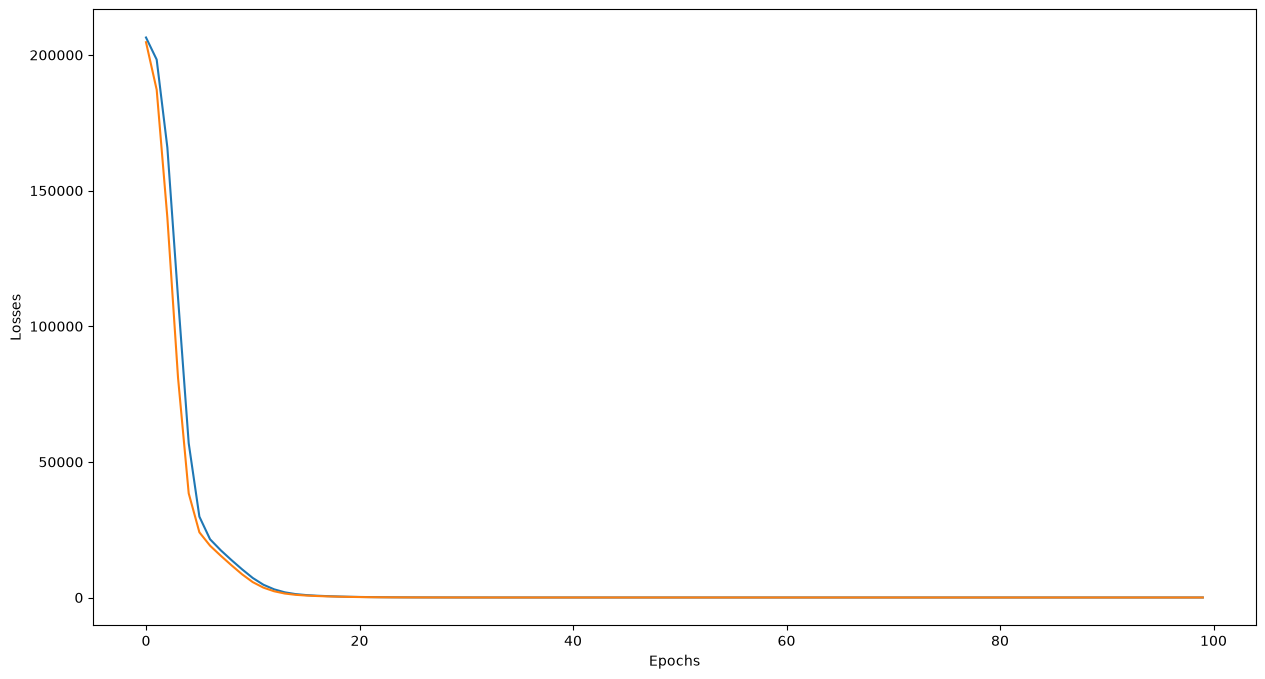

In [24]:
import matplotlib.pyplot as plt

loss_df=pd.DataFrame(
    {
        "training_loss":train_losses,
        "validation_loss":validation_losses
    }
)
plt.figure(figsize=(15,8))
plt.plot(loss_df["training_loss"],label="Training loss")
plt.plot(loss_df["validation_loss"],label="Validation loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.legend

In [25]:
# Load the best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [29]:
# Evaluate

model.eval()
with torch.no_grad():
    train_preds=model(X_train_tensor)
    test_preds=model(X_test_tensor)

    train_mse=criterion(train_preds,y_train_tensor)
    test_mse=criterion(test_preds,y_test_tensor)

print("Training MSE:",train_mse.item())
print("Testing MSE:",test_mse.item())

Training MSE: 20.22759246826172
Testing MSE: 18.399024963378906


In [30]:
from sklearn.metrics import r2_score

print("R2 Score:",r2_score(y_test,test_preds))

R2 Score: 0.9357001556868105


In [32]:
predicted_df=pd.DataFrame(test_preds.numpy(),columns=["Predicted Values"])
actual_df=pd.DataFrame(y_test.values,columns=["Actual Values"])

In [33]:
pd.concat([predicted_df,actual_df],axis=1)

,Predicted Values,Actual Values
0,435.110748,433.27
1,436.706238,438.16
2,461.025299,458.42
3,475.987244,480.82
4,435.055328,441.41
...,...,...
1909,451.173798,456.70
1910,431.435822,438.04
1911,467.441589,467.80
1912,430.852783,437.14
